In [4]:
# Cell lineage analysis in hyperbolic space
import numpy as np
import pandas as pd
import seaborn as sn
import pylab as plt

import sys
sys.path.append('../')
import MHMDS.embed_funs as emb
import MHMDS.quality_metrics as qms

# simple PCA
from sklearn.decomposition import PCA
import umap

from scipy.optimize import minimize
from scipy import stats

import scanpy as sc

# plotting settings
import plotly

In [2]:
# plot parameters
plt.style.use('my_journal.mplstyle')
def clean_axis(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3)


In [5]:
# setting colors
colorssel = plotly.colors.qualitative.Plotly

In [6]:
# function to generate colormap
# setting colors
colorssel = plotly.colors.qualitative.Plotly

def generate_colormap(start):
    # n is the "start string"
    return {start:'#7F7F7F',
             start+'a':colorssel[0],start+'p':colorssel[1],
             start+'aa':colorssel[3],start+'ap':colorssel[5],start+'pa':colorssel[4],start+'pp':colorssel[6],}


In [7]:
# get PCA and UMAP, and compute Qlocal, Qglobal
def get_pca_umap(featmat,pcoords):
    dim = pcoords.shape[1]
    # get PCA and umap embedding in the same dimension
    pca = PCA(n_components=dim)
    pcmat = pca.fit_transform(featmat)

    reducer = umap.UMAP(n_components=dim,random_state=42)
    umapmat = reducer.fit_transform(featmat)

    return pcmat,umapmat

def compute_quality_metrics(featmat,pcoords,pcmat,umapmat,plot=False):
    distmat = emb.get_dmat_euc(featmat)
    # compute Q local and Q global
    qlocal, qglobal, _ = qms.get_quality_metrics(distmat,emb.get_dmat_poin(pcoords))

    # compute Q local and Q global
    qlocal_pca, qglobal_pca, _ = qms.get_quality_metrics(distmat,emb.get_dmat_euc(pcmat))
    qlocal_umap, qglobal_umap, _ = qms.get_quality_metrics(distmat,emb.get_dmat_euc(umapmat))

    # visualization
    # scatter plot of Q local and Q global for PCA, UMAP and hMDS
    if plot:
        fig, ax = plt.subplots()
        ax.scatter(qlocal, qglobal, label='hMDS')
        ax.scatter(qlocal_pca, qglobal_pca, label='PCA')
        ax.scatter(qlocal_umap, qglobal_umap, label='UMAP')
        ax.set_xlabel('Q local')
        ax.set_ylabel('Q global')
        ax.legend()
        plt.show()

    return {'hyperbolic':[qlocal, qglobal],
                          'pca':[qlocal_pca, qglobal_pca],
                          'umap':[qlocal_umap, qglobal_umap]}


In [8]:
# project to visualize the embedding, at any "starting point"
'''
for each "start point" s, plot the following lineages:
s, sa, sp, saa, sap, spa, spp
for each plot, project to two dimensions: one that maximizes change in the depth (length of lineage name)
one that maximizes ap axis at the lowest level
'''
def mygoal(proj_target,coords,metric,method = 'pearson'):
    proj_target = proj_target/np.linalg.norm(proj_target)
    projs = np.dot(coords, proj_target)  
    if method == 'pearson':
        corr, p = stats.pearsonr(projs, metric)
    elif method == 'spearman':
        corr, p = stats.spearmanr(projs, metric)
    else:
        raise ValueError("Method must be 'pearson' or 'spearman'")
    return -corr


In [9]:
def get_sublineage_ind(lineage_name,lineage_labels,lineage_depth_labels,sub_depth):
    currlen = len(lineage_name)
    sel = np.where((lineage_labels.str.startswith(lineage_name,na=False))&(lineage_depth_labels<=currlen+sub_depth-1))[0]
    return sel


In [10]:
def proj_gen_ap(lineage_name,metadata,tangent_coords,aplabelmap, split = False):
    currlen = len(lineage_name)

    sel = get_sublineage_ind(lineage_name, metadata.lineage, metadata.generation_label, 3)
    x0 = np.mean(tangent_coords[np.isin(metadata.lineage.astype(str),[lineage_name+'p',lineage_name+'a']),:],
                          axis=0)-np.mean(tangent_coords[metadata.lineage.astype(str)==lineage_name,:],axis=0)
    # assign a-p labels
    tofit = metadata['lineage'][sel]
    ap_label = np.array([aplabelmap[name[currlen:]] for name in tofit])
    metadata['ap_label'] = np.nan
    metadata.loc[sel,'ap_label'] = ap_label

    if split: 
        # split data into train and test (50% each), randomly
        # use train to fit the res, and test to compute correlation
        train_ind = np.random.choice(sel, size=int(len(sel)/2), replace=False)
        test_ind = np.setdiff1d(sel, train_ind)

        res_gen = minimize(mygoal, x0, args=(tangent_coords[train_ind,:],metadata['generation_label'][train_ind]), 
                        method='L-BFGS-B',tol=1e-12)
        test_gen = mygoal(res_gen.x, tangent_coords[test_ind,:], metadata['generation_label'][test_ind],method='pearson')
        res_ap = minimize(mygoal, x0, args=(tangent_coords[train_ind,:],metadata['ap_label'][train_ind]), method='L-BFGS-B',
                       tol=1e-12)
        test_ap = mygoal(res_ap.x, tangent_coords[test_ind,:], metadata['ap_label'][test_ind],method='pearson')

    else:
        # maximize correlation in generation
        res_gen = minimize(mygoal, x0, args=(tangent_coords[sel,:],metadata['generation_label'][sel]), method='L-BFGS-B',
                    tol=1e-12)
        test_gen = mygoal(res_gen.x, tangent_coords[sel,:], metadata['generation_label'][sel],method='pearson')
        # maximize correlation in the a-p axis
        res_ap = minimize(mygoal, x0, args=(tangent_coords[sel,:],metadata['ap_label'][sel]), method='L-BFGS-B',
                    tol=1e-12)
        test_ap = mygoal(res_ap.x, tangent_coords[sel,:], metadata['ap_label'][sel],method='pearson')
        
    
    df_return = metadata.copy()
    df_return['gen_proj'] = np.dot(tangent_coords,res_gen.x)
    df_return['ap_proj'] = np.dot(tangent_coords,res_ap.x)
    return df_return,test_gen,test_ap

In [11]:
def pseudotime_corr(lineage_name,metadata,mat): 
    # for a given lineage name, compute pseudotime, return pseudotime each point and correlation with generation label
    # recenter based on certain groups

    sel = get_sublineage_ind(lineage_name,metadata.reset_index().lineage, metadata.reset_index().generation_label, 3)
    adata = sc.AnnData(X=mat[sel,:],)
    # important metadata labels
    adata.obs['lineage'] = np.array(metadata.lineage.iloc[sel].astype(str))
    adata.obs['generation_label'] = np.array(metadata.generation_label.iloc[sel])
    adata.obs['embryo.time'] = np.array(metadata['embryo.time'].iloc[sel])
    sc.pp.neighbors(adata, n_neighbors=10, use_rep='X')

    # start point is the cloest point to the mean of start lineage
    startlins_ind = np.where(adata.obs['lineage'] == lineage_name)[0]
    startlin_mean = np.mean(adata.X[startlins_ind,:],axis=0)
    # find the closest point to the mean of start lineage
    dists = np.linalg.norm(adata.X - startlin_mean, axis=1)[startlins_ind]
    start_ind = startlins_ind[np.argmin(dists)]
    # print('Start index for lineage',lineage_name,start_ind,adata.obs['lineage'].iloc[start_ind])
    adata.uns['iroot'] = start_ind # start lineage is the root

    sc.tl.diffmap(adata, n_comps=10) # use neighbor graph to compute diffusion map
    sc.tl.dpt(adata)
    pseudotime = adata.obs['dpt_pseudotime']


    # correlation between pseudo time and generation label, only for pseudo time != inf
    ind_  = np.where(~np.isinf(pseudotime))[0]
    corr, p = stats.pearsonr(adata.obs['generation_label'][ind_], pseudotime[ind_])

    df_ = metadata.copy().reset_index()
    df_['pseudotime'] = np.nan

    # df_.loc[sel[ind_], 'pseudotime'] = np.array(pseudotime[ind_])
    df_.loc[sel, 'pseudotime'] = np.array(pseudotime)


    return df_, corr


In [12]:
def rc_radius_corr(lineage_name,metadata,mat,mode):
    # recenter based on certain groups

    inds_stlin = np.where(metadata['lineage']==lineage_name)[0]
    if mode == 'hyperbolic':
        # change tangent coordinates to poincare coordinates
        mat = emb.expmap(mat)
        data_recenter = emb.perform_recenter(mat,inds_stlin) # recenter based on the start lineage
        data_recenter = emb.to_native(data_recenter)
    elif mode == 'euclidean':
        data_recenter = mat - np.mean(mat[inds_stlin,:],axis=0) # recenter 
    # convert to native coordinates
    rads = np.linalg.norm(data_recenter,axis=1)

    # slice 3-generation lineages from start lineage
    inds_sublin = get_sublineage_ind(lineage_name,metadata.reset_index().lineage,metadata.reset_index().generation_label,
                   3)

    # correlation
    corr, p = stats.pearsonr(metadata.iloc[inds_sublin]['generation_label'],rads[inds_sublin])

    df_ = metadata.copy()
    df_['rc_radius'] = rads

    return df_, corr


In [13]:
def set_axs(axs,x='',y='',title=''):
    axs.set_title(title,fontsize=15)
    axs.set_xlabel(x,fontsize=15)
    axs.set_ylabel(y,fontsize=15)
    axs.tick_params(axis="x", labelsize=12)  
    axs.tick_params(axis="y", labelsize=12)
def plot_my(lilist,df_toplot,coords,aplabelmap,colormetric = 'proj', mode = None,centroid_lines=False):
    # color metric can be : proj, pseudotime, rc_radius
    dfs = []
    corr1s = []
    corr2s = []
    for li_ in lilist:
        df_, corr1, corr2 = proj_gen_ap(li_,df_toplot,coords,aplabelmap, split=False)
        dfs.append(df_)
        corr1s.append(corr1)
        corr2s.append(corr2)
    # plot 6 different lineages
    fig,axs = plt.subplots(round(len(lilist)/3),3,figsize=(10,round(len(lilist)/3)*3))
    axs = axs.flatten()
    for i in range(len(lilist)):
        if colormetric == 'proj':
            sn.scatterplot(data=dfs[i][(dfs[i].lineage.str.startswith(lilist[i]))&
                                    (dfs[i]['generation_label']<=len(lilist[i])+2)],
                    x='gen_proj',y='ap_proj',hue='lineage',
                    palette=generate_colormap(lilist[i]),ax=axs[i],s=40,edgecolor="none")
            axs[i].get_legend().remove()
            set_axs(axs[i],'','',
                lilist[i]+': \n corr1 = '+str(-round(corr1s[i],2))+', corr2 = '+str(-round(corr2s[i],2)))
            if centroid_lines:
                    data_ = dfs[i][(dfs[i].lineage.str.startswith(lilist[i]))&
                                            (dfs[i]['generation_label']<=len(lilist[i])+2)]
                    aggdata = data_[['lineage','gen_proj','ap_proj']].groupby('lineage').mean()
                    sn.scatterplot(data = aggdata, x='gen_proj',y='ap_proj',hue='lineage',ax=axs[i],palette=generate_colormap(lilist[i]),
                                s=100,marker = '^', edgecolor='black',linewidth = 1, legend=False)
                    
                    # plot lines connecting the lineages
                    connlist = [[lilist[i],lilist[i]+'a',lilist[i]+'p'],
                                [lilist[i]+'a',lilist[i]+'aa',lilist[i]+'ap'],
                                [lilist[i]+'p',lilist[i]+'pa',lilist[i]+'pp']]
                    for conn in connlist:
                        for j in range(2):
                            if (conn[0] in aggdata.index) and (conn[j+1] in aggdata.index):
                                axs[i].plot([aggdata.loc[conn[0],'gen_proj'],aggdata.loc[conn[j+1],'gen_proj']],
                                            [aggdata.loc[conn[0],'ap_proj'],aggdata.loc[conn[j+1],'ap_proj']],
                                            color='black',linewidth=1.0)
            
        elif colormetric == 'pseudotime':
            # run pseudotime analysis
            df_, corr1 = pseudotime_corr(lilist[i],dfs[i],coords)
            df_['pseudotime_plot'] = df_['pseudotime'].copy()

            normal_pts = df_[~np.isinf(df_['pseudotime'])]
            inf_pts = df_[np.isinf(df_['pseudotime'])]

            sn.scatterplot(data=normal_pts[(normal_pts.lineage.str.startswith(lilist[i]))&
                                    (normal_pts['generation_label']<=len(lilist[i])+2)&
                                    (~normal_pts['pseudotime_plot'].isna())],
                    x='gen_proj',y='ap_proj',hue='pseudotime_plot',ax=axs[i],s=40,edgecolor="none")
            axs[i].scatter(inf_pts['gen_proj'], inf_pts['ap_proj'], color='red', label='inf')
            # axs[i].get_legend().remove()
            set_axs(axs[i],'','',
                lilist[i]+': \n corr = '+str(-round(corr1,2)))
            # remove legend except for the first plot
            if i == 0:
                axs[i].legend(title='Pseudotime', fontsize=12, title_fontsize='13')
            else:
                axs[i].get_legend().remove()

        elif colormetric == 'rc_radius':
            # run radius correlation analysis
            if mode is None:
                raise ValueError("Mode must be specified: 'hyperbolic' or 'euclidean'")
            df_, corr1 = rc_radius_corr(lilist[i],dfs[i],coords,mode)
            toplot = df_[(df_.lineage.str.startswith(lilist[i]))&
                                    (df_['generation_label']<=len(lilist[i])+2)].copy()
            toplot['normalized_radius'] = toplot['rc_radius']/np.max(toplot['rc_radius'])
            sn.scatterplot(data=toplot,
                    x='gen_proj',y='ap_proj',hue='normalized_radius',ax=axs[i],s=40,edgecolor="none")
            # axs[i].get_legend().remove()
            set_axs(axs[i],'','',
                lilist[i]+': \n corr = '+str(-round(corr1,2)))
            # remove legend except for the first plot
            if i == 0:
                axs[i].legend(title='Normalized Radius', fontsize=12, title_fontsize='13')
            else:
                axs[i].get_legend().remove()
    # set supxlabel and supylabel
    # remove subplot x and y labels
    for ax in axs:
        ax.set_xlabel('')
        ax.set_ylabel('')
    fig.supylabel('A-P Axis Projection', fontsize=15)
    fig.supxlabel('Generation Axis Projection', fontsize=15)


    plt.tight_layout()
    # return statistics
    return dfs,fig,axs

In [14]:
def project_to_subspace(coord,metadata,lineagelist,aplabelmap,metrics_list,low_d = False, split = False, mode = None):
    # metrics_list: metrics to compute, e.g. ['proj','pseudotime','rc_radius']. return as a dict
    # coordlist: list of coordinates to project to
    if low_d: # reduce coords to 3D by PCA before projection
        pca = PCA(n_components=3)
        coord = pca.fit_transform(coord)

    # compute features on lineage
    df_toplot = metadata.copy()

    res = {}
    for metric in metrics_list:
        if metric == 'proj':
            # project to subspace
            corr1s = []
            corr2s = []
            for li_ in lineagelist:
                _, corrgen, corrap = proj_gen_ap(li_,df_toplot,coord,aplabelmap, split=split)
                corr1s.append(corrgen)
                corr2s.append(corrap)
            res['proj'] = {'corr_gen': dict(zip(lineagelist,corr1s)),
                           'corr_ap': dict(zip(lineagelist,corr2s))}
        elif metric == 'pseudotime':
            # compute pseudotime correlation
            corr1s = []
            for li_ in lineagelist:
                _, corr1 = pseudotime_corr(li_,df_toplot,coord)
                corr1s.append(corr1)
            res['pseudotime'] = dict(zip(lineagelist,corr1s))
        elif metric == 'rc_radius':
            # compute radius correlation
            if mode is None:
                raise ValueError("Mode must be specified for rc_radius correlation, either 'hyperbolic' or 'euclidean'")
            corr1s = []
            for li_ in lineagelist:
                _, corr1 = rc_radius_corr(li_,df_toplot,coord,mode)
                corr1s.append(corr1)
            res['rc_radius'] = dict(zip(lineagelist,corr1s))

    return res

In [15]:
# get tangent coordinates
def get_tangent_coords(pcoords):
    N_sample = pcoords.shape[0]
    data_recenter = emb.perform_recenter(pcoords,np.arange(N_sample))
    tangent_coords = emb.logmap(data_recenter)
    return tangent_coords

In [16]:
# load data: metadata and features
metadata = pd.read_csv('../data/metadata/Celegans_PCA50_lineage_ABpxp_metadata.csv',index_col=0)
# label lineage
generation_label = np.array([len(name) for name in metadata.lineage])
metadata['generation_label'] = generation_label

# load original feature matrix
featmat = np.loadtxt('../data/FeatMat_Celegans_PCA50_lineage_ABpxp/FeatMat_Celegans_PCA50_lineage_ABpxp.txt')

In [17]:
aplabelmap = {'':0,'a':1,'p':-1,'aa':1.5,'ap':0.5,'pa':-0.5,'pp':-1.5}

In [18]:
# load data: individual embedding, from 2 - 10 dimensions
dir = '../MultiscalehMDS_feature/result/FeatMat_Celegans_PCA50_lineage_ABpxp/'

# arrays for recording results
metrics_list = []

# for dim in range(3,11):
#     print('Processing dimension %d'%(dim))
#     pcoords = np.loadtxt(dir+'cls_50_Nn_20_Nd_%s_min_3_max_400_coords_7562.txt'%(dim))
#     inds = np.loadtxt(dir+'cls_50_Nn_20_Nd_%s_min_3_max_400_inds_after_prep.txt'%(dim))
#     pcoords = pcoords[np.argsort(inds)]
#     print('computing PCA and UMAP, and Qlocal, Qglobal')
#     # given feature matrix, compute PCA and UMAP, and compute Qlocal, Qglobal
#     pcamat, umapmat = get_pca_umap(featmat,pcoords)
#     metrics = compute_quality_metrics(featmat,pcoords,pcamat,umapmat,plot=False)
#     # record the results
#     metrics_list.append(metrics)
# # convert metric list to dataframe, label the dimension
# df_metrics = pd.DataFrame(columns=['method','dim','Qlocal','Qglobal'])
# for i in range(len(metrics_list)):
#     for method in metrics_list[i].keys():
#         df_metrics = pd.concat([df_metrics,pd.DataFrame({'method':method,'dim':i+3,
#                                         'Qlocal':metrics_list[i][method][0],
#                                         'Qglobal':metrics_list[i][method][1]},index=[0])],ignore_index=True)

# df_metrics.to_csv('./metrics_Abpxp.csv')
# or load metrics directly
df_metrics = pd.read_csv('./metrics_Abpxp.csv',index_col=0)

In [19]:
# load data: individual embedding, from 2 - 10 dimensions
dir = './additional_metric_241111/FeatMat_Celegans_PCA50_lineage_ABpxp/'

# # arrays for recording results
# corrs = pd.DataFrame(columns=['method','dim','lineage','corr_gen','corr_ap',
#                               # 'corr_gen_low_d','corr_ap_low_d',
#                               'local-global','local-global-num'])

# for dim in range(3,11):
# # for dim in [10]:
#     print('Processing dimension %d'%(dim))
#     pcoords = np.loadtxt(dir+'cls_50_Nn_20_Nd_%s_min_3_max_400_coords_7562.txt'%(dim))
#     inds = np.loadtxt(dir+'cls_50_Nn_20_Nd_%s_min_3_max_400_inds_after_prep.txt'%(dim))
#     pcoords = pcoords[np.argsort(inds)]
#     print('computing PCA and UMAP')
#     # given feature matrix, compute PCA and UMAP, and compute Qlocal, Qglobal
#     pcamat, umapmat = get_pca_umap(featmat,pcoords)
#     print('computing Qlocal, Qglobal')
#     # metrics = compute_quality_metrics(featmat,pcoords,pcamat,umapmat,plot=False)
#     # subsequent analysis: for each lineage, project to the tangent space, and visualize the projection
#     tangent_coords = get_tangent_coords(pcoords)

#     lilist1 = ['ABpxpppp','ABpxpppa','ABpxppap','ABpxppaa','ABpxpaap','ABpxpaaa']
#     lilist2 = ['ABpxp','ABpxpp','ABpxpa','ABpxppp','ABpxppa','ABpxpap','ABpxpaa']

#     lilist = lilist1+lilist2

#     localglobal = ['local']*len(lilist1)+['global']*len(lilist2)
#     localglobal_num = [len(name)-4 for name in lilist]
    
#     names = ['hMDS','PCA','UMAP']
#     for kk,mats in enumerate([tangent_coords,pcamat,umapmat]):
#         for reps in range(20):
#           res1 = project_to_subspace(mats,metadata.reset_index(),lilist,aplabelmap,['proj'], 
#                     low_d = False, split = True)
#           corr1 = res1['proj']['corr_gen']
#           corr2 = res1['proj']['corr_ap']
#           # corr1, corr2 = project_to_subspace(mats,metadata.reset_index(),lilist,aplabelmap,plot=False,low_d=False,split=True)
#           # corr1_ld, corr2_ld = project_to_subspace(mats,metadata.reset_index(),lilist,aplabelmap,plot=False,low_d=True)
#           # unzip corr1 and record
#           for k in range(len(lilist)):
#               corrs = pd.concat([corrs,pd.DataFrame({'method':names[kk],
#                                 'dim':dim,
#                                 'lineage':lilist[k],
#                                 'corr_gen':corr1[lilist[k]],
#                                 'corr_ap':corr2[lilist[k]],
#                                   # 'corr_gen_low_d':corr1_ld[lilist[k]],
#                                   # 'corr_ap_low_d':corr2_ld[lilist[k]],
#                                 'local-global':localglobal[k],
#                                 'local-global-num':localglobal_num[k]},index=[0])],ignore_index=True)

#     # print(corrs.head())
#     # record the results
#     # metrics_list.append(metrics)


# corrs.to_csv('./corrs_proj_Abpxp_20reps.csv',index=False)
# or load corrs directly
corrs_proj = pd.read_csv('./corrs_proj_Abpxp_20reps.csv',index_col=None)

corrs_proj['method'] = corrs_proj['method'].replace({'hMDS':'MuH-MDS'})
corrs_proj['corr_ap'] = -corrs_proj['corr_ap']
corrs_proj['corr_gen'] = -corrs_proj['corr_gen']



In [20]:
# load data: individual embedding, from 2 - 10 dimensions
dir = './additional_metric_241111/FeatMat_Celegans_PCA50_lineage_ABpxp/'

# # arrays for recording results
# corrs = pd.DataFrame(columns=['method','dim','lineage','corr_pseudotime','corr_rc_radius',
#                               # 'corr_gen_low_d','corr_ap_low_d',
#                               'local-global','local-global-num'])

# for dim in range(3,11):
# # for dim in [10]:
#     print('Processing dimension %d'%(dim))
#     pcoords = np.loadtxt(dir+'cls_50_Nn_20_Nd_%s_min_3_max_400_coords_7562.txt'%(dim))
#     inds = np.loadtxt(dir+'cls_50_Nn_20_Nd_%s_min_3_max_400_inds_after_prep.txt'%(dim))
#     pcoords = pcoords[np.argsort(inds)]
#     print('computing PCA and UMAP')
#     # given feature matrix, compute PCA and UMAP, and compute Qlocal, Qglobal
#     pcamat, umapmat = get_pca_umap(featmat,pcoords)
#     print('computing Qlocal, Qglobal')
#     # metrics = compute_quality_metrics(featmat,pcoords,pcamat,umapmat,plot=False)
#     # subsequent analysis: for each lineage, project to the tangent space, and visualize the projection
#     tangent_coords = get_tangent_coords(pcoords)

#     lilist1 = ['ABpxpppp','ABpxpppa','ABpxppap','ABpxppaa','ABpxpaap','ABpxpaaa']
#     lilist2 = ['ABpxp','ABpxpp','ABpxpa','ABpxppp','ABpxppa','ABpxpap','ABpxpaa']

#     lilist = lilist1+lilist2

#     localglobal = ['local']*len(lilist1)+['global']*len(lilist2)
#     localglobal_num = [len(name)-4 for name in lilist]
    
#     names = ['hMDS','PCA','UMAP']
#     for kk,mats in enumerate([tangent_coords,pcamat,umapmat]):
#         if names[kk] == 'hMDS':
#             curr_mode = 'hyperbolic'
#         else:
#             curr_mode = 'euclidean'
#         res1 = project_to_subspace(mats,metadata.reset_index(),lilist,aplabelmap,['pseudotime','rc_radius'], 
#                 low_d = False, split = True, mode=curr_mode)
#         corr1 = res1['pseudotime']
#         corr2 = res1['rc_radius']
#           # corr1, corr2 = project_to_subspace(mats,metadata.reset_index(),lilist,aplabelmap,plot=False,low_d=False,split=True)
#           # corr1_ld, corr2_ld = project_to_subspace(mats,metadata.reset_index(),lilist,aplabelmap,plot=False,low_d=True)
#           # unzip corr1 and record
#         for k in range(len(lilist)):
#             corrs = pd.concat([corrs,pd.DataFrame({'method':names[kk],
#                               'dim':dim,
#                               'lineage':lilist[k],
#                               'corr_pseudotime':corr1[lilist[k]],
#                               'corr_rc_radius':corr2[lilist[k]],
#                                 # 'corr_gen_low_d':corr1_ld[lilist[k]],
#                                 # 'corr_ap_low_d':corr2_ld[lilist[k]],
#                               'local-global':localglobal[k],
#                               'local-global-num':localglobal_num[k]},index=[0])],ignore_index=True)

#     # print(corrs.head())
#     # record the results
#     # metrics_list.append(metrics)

# corrs.to_csv('./exps_0601/corrs_pesudotime_rcradius_Abpxp.csv',index=False)

# or load corrs directly
corrs_pseudorcrad = pd.read_csv('./corrs_pesudotime_rcradius_Abpxp.csv',index_col=None)

corrs_pseudorcrad['method'] = corrs_pseudorcrad['method'].replace({'hMDS':'MuH-MDS'})

In [21]:
palette ={"PoincareMap": "C0", "PHATE": "C1", "ForceAtlas2": "C2", 
          'UMAP':'C3','t-sne':'C4','DiffMap':'C5','SIMLR':'C6',
          'SAUCIE':'C7','PCA':'C8','MuH-MDS':'k'}

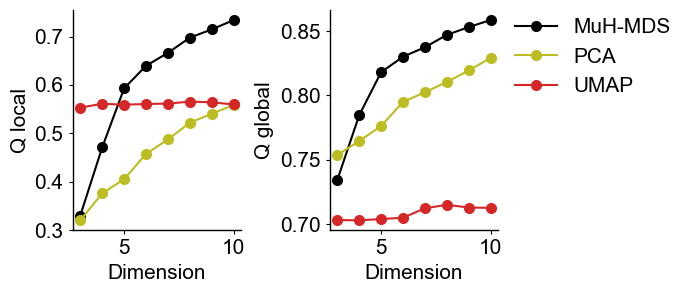

In [22]:
# plot change in metrics
# set legend names
df_metrics['method'] = df_metrics['method'].replace({'hyperbolic':'MuH-MDS','pca':'PCA','umap':'UMAP'})
fig,axs = plt.subplots(1,2,figsize=(7,3))
sn.lineplot(data=df_metrics,x='dim',y='Qlocal',hue='method',ax=axs[0],marker='o',markeredgewidth=0,markersize=8,palette=palette)

axs[0].set_xlabel('Dimension',fontsize=15)  
axs[0].set_ylabel('Q local',fontsize=15)
# remove legend for axs[0]
axs[0].legend([],[],frameon=False)
sn.lineplot(data=df_metrics,x='dim',y='Qglobal',hue='method',ax=axs[1],marker='o',markeredgewidth=0,markersize=8,palette=palette)

axs[1].set_xlabel('Dimension',fontsize=15)
axs[1].set_ylabel('Q global',fontsize=15)
# set tick font size
axs[0].tick_params(axis="x", labelsize=15,direction='in')
axs[0].tick_params(axis="y", labelsize=15,direction='in')
axs[1].tick_params(axis="x", labelsize=15,direction='in')
axs[1].tick_params(axis="y", labelsize=15,direction='in')
# set 
axs[1].legend(fontsize=15,bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
clean_axis(axs[0])
clean_axis(axs[1])
plt.tight_layout()

# plt.savefig('metrics_dim_Abpxp.svg',format='svg',transparent=True)

In [23]:
lilist1 = ['ABpxpppp','ABpxpppa','ABpxppap','ABpxppaa','ABpxpaap','ABpxpaaa']
lilist2 = ['ABpxp','ABpxpp','ABpxpa','ABpxppp','ABpxppa','ABpxpap','ABpxpaa']

lilist = lilist1+lilist2

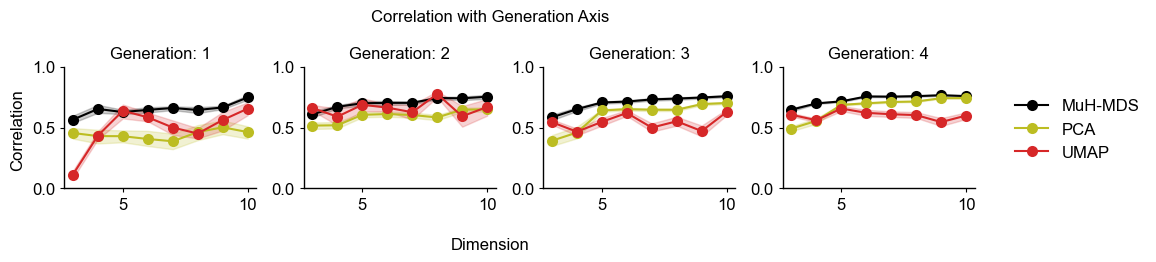

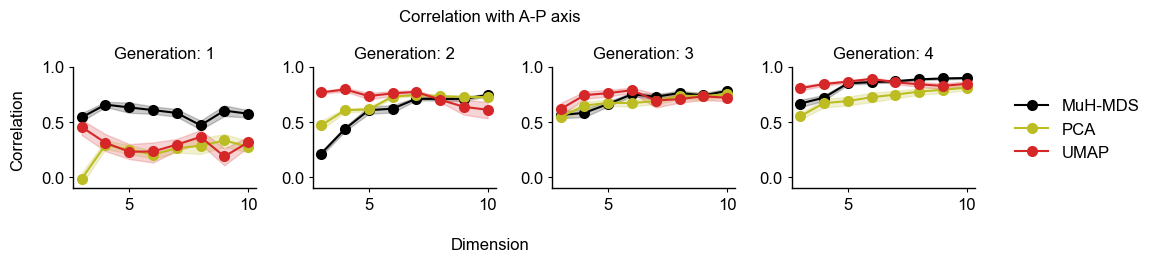

In [24]:
plotlins = 4
fig,axs = plt.subplots(1,plotlins,figsize=(plotlins*2.5,2.5))
# colormap = {'global':'red','local':'blue'}

for i in range(plotlins):
    sel = corrs_proj[corrs_proj['local-global-num'] == i+1]
    # plot each lineage 
    sn.lineplot(data=sel, x='dim', y='corr_gen', hue='method',ax=axs[i],
                marker='o',markeredgewidth=0,markersize=8,palette=palette)
    axs[i].set_title('Generation: %d'%(i+1),fontsize=12)
    
    axs[i].set_ylim([0,1.0])
    axs[i].tick_params(axis="x", labelsize=12)
    axs[i].tick_params(axis="y", labelsize=12)
    clean_axis(axs[i])
for ax in axs:
    ax.set_xlabel(None)
    ax.set_ylabel(None)
fig.supxlabel("Dimension",fontsize =12)  
fig.supylabel("Correlation",fontsize =12)  
fig.suptitle("Correlation with Generation Axis",fontsize=12)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5),fontsize=12)
for ax in axs:
    ax.legend().remove()
plt.tight_layout()
# plt.show()

# plt.savefig('./%i_Proj_metrics_generation.svg'%plotlins,format='svg',transparent=True)

fig,axs = plt.subplots(1,plotlins,figsize=(plotlins*2.5,2.5))

for i in range(plotlins):
    sel = corrs_proj[corrs_proj['local-global-num'] == i+1]
    # plot each lineage 
    sn.lineplot(data=sel, x='dim', y='corr_ap', hue='method',ax=axs[i],
                marker='o',markeredgewidth=0,markersize=8,palette=palette)
    axs[i].set_title('Generation: %d'%(i+1),fontsize=12)
    axs[i].set_xlabel('Dimension',fontsize=12)
    axs[i].set_ylim([-0.1,1.0])
    axs[i].tick_params(axis="x", labelsize=12)
    axs[i].tick_params(axis="y", labelsize=12)
    clean_axis(axs[i])
for ax in axs:
    ax.set_xlabel(None)
    ax.set_ylabel(None)
fig.supxlabel("Dimension",fontsize =12)  
fig.supylabel("Correlation",fontsize =12)  
fig.suptitle("Correlation with A-P axis",fontsize=12)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5),fontsize=12)
for ax in axs:
    ax.legend().remove()
plt.tight_layout()

# plt.savefig('./%i_Proj_metrics_ap.svg'%plotlins,format='svg',transparent=True)

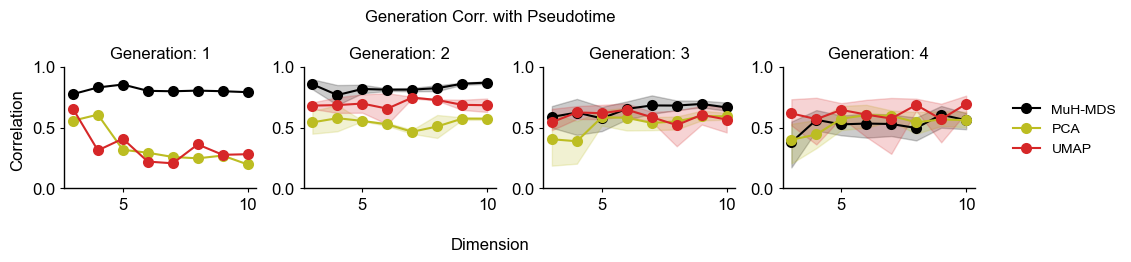

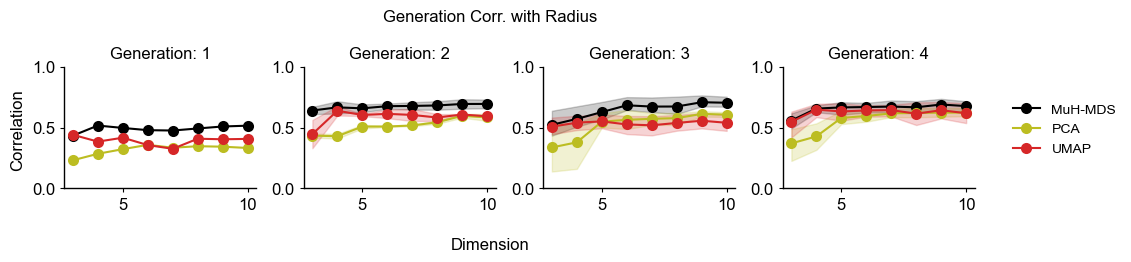

In [25]:
plotlins = 4
fig,axs = plt.subplots(1,plotlins,figsize=(plotlins*2.5,2.5))
# colormap = {'global':'red','local':'blue'}

for i in range(plotlins):
    sel = corrs_pseudorcrad[corrs_pseudorcrad['local-global-num'] == i+1]
    # plot each lineage 
    sn.lineplot(data=sel, x='dim', y='corr_pseudotime', hue='method',ax=axs[i],
                marker='o',markeredgewidth=0,markersize=8,palette=palette)
    axs[i].set_title('Generation: %d'%(i+1),fontsize=12)
    axs[i].set_ylim([0,1.0])
    axs[i].tick_params(axis="x", labelsize=12)
    axs[i].tick_params(axis="y", labelsize=12)
    clean_axis(axs[i])
fig.supxlabel("Dimension",fontsize =12)  
fig.supylabel("Correlation",fontsize =12)
fig.suptitle("Generation Corr. with Pseudotime",fontsize=12)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5))
for ax in axs:
    ax.legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
# plt.show()

fig,axs = plt.subplots(1,plotlins,figsize=(plotlins*2.5,2.5))

for i in range(plotlins):
    sel = corrs_pseudorcrad[corrs_pseudorcrad['local-global-num'] == i+1]
    # plot each lineage 
    sn.lineplot(data=sel, x='dim', y='corr_rc_radius', hue='method',ax=axs[i],
                marker='o',markeredgewidth=0,markersize=8,palette=palette)
    axs[i].set_title('Generation: %d'%(i+1),fontsize=12)
    axs[i].set_xlabel('Dimension',fontsize=12)
    axs[i].set_ylabel('Generation Corr. with Radius',fontsize=12)
    axs[i].set_ylim([0,1.0])
    axs[i].tick_params(axis="x", labelsize=12)
    axs[i].tick_params(axis="y", labelsize=12)
    clean_axis(axs[i])
fig.supxlabel("Dimension",fontsize =12)  
fig.supylabel("Correlation",fontsize =12)
fig.suptitle("Generation Corr. with Radius",fontsize=12)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5))
for ax in axs:
    ax.legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
# plt.show()



In [ ]:
# visualize the embedding projecting to 2-d, with any disired lineage or dimensions
# title by correlation to the A-P axis or generation axis
dir = '../MultiscalehMDS_feature/result/FeatMat_Celegans_PCA50_lineage_ABpxp/'

dim = 7
print('Processing dimension %d'%(dim))
pcoords = np.loadtxt(dir+'cls_50_Nn_20_Nd_%s_min_3_max_400_coords_7562.txt'%(dim))
inds = np.loadtxt(dir+'cls_50_Nn_20_Nd_%s_min_3_max_400_inds_after_prep.txt'%(dim))
pcoords = pcoords[np.argsort(inds)]
print('computing PCA and UMAP')
# given feature matrix, compute PCA and UMAP, and compute Qlocal, Qglobal
pcamat, umapmat = get_pca_umap(featmat,pcoords)
# subsequent analysis: for each lineage, project to the tangent space, and visualize the projection
tangent_coords = get_tangent_coords(pcoords)

lilist = ['ABpxp','ABpxpp','ABpxpa']

localglobal = ['local']*len(lilist1)+['global']*len(lilist2)
localglobal_num = [len(name)-4 for name in lilist]

names = ['MuH-MDS','PCA','UMAP']


Processing dimension 7
computing PCA and UMAP


/Users/mingchen/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
14:20:43 - cmdstanpy - INFO - Chain [1] start processing
14:20:43 - cmdstanpy - INFO - Chain [1] done processing


/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_65047/1162366306.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_65047/1162366306.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/x4/m6sn1g5s4yjb6ybj1mpz8c600000gn/T/ipykernel_65047/1162366306.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


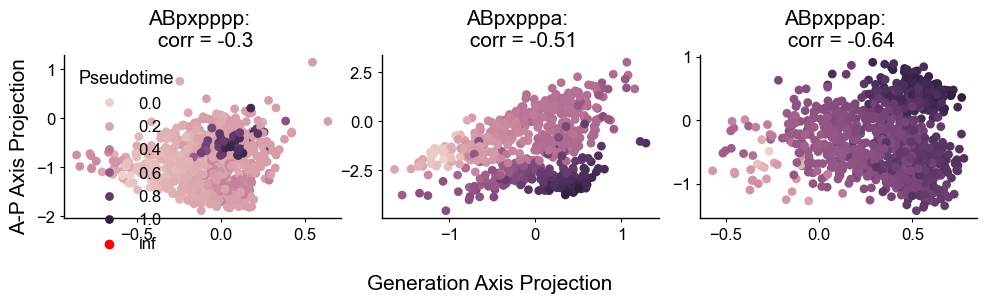

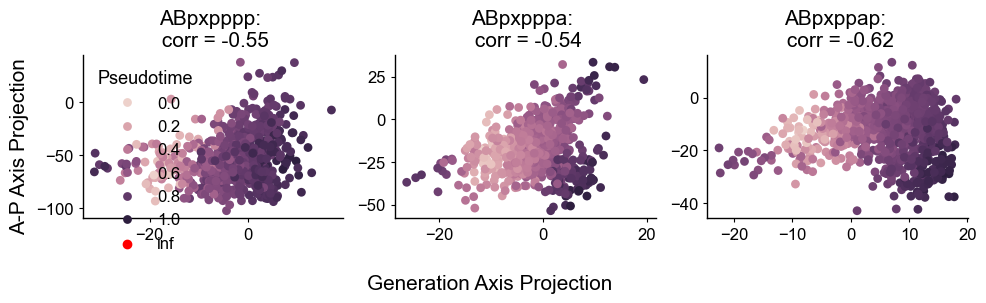

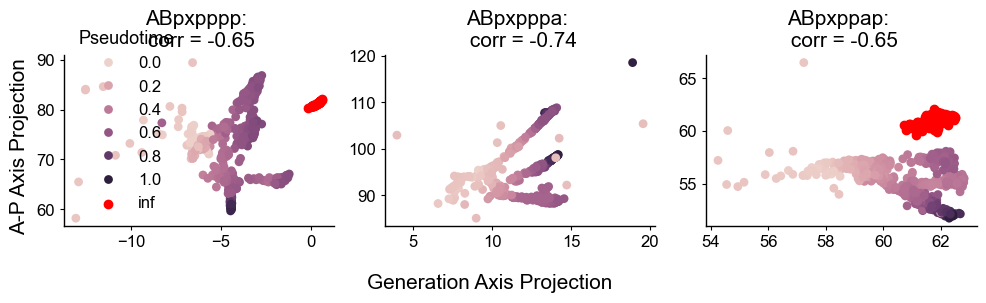

In [28]:
# lilist = ['ABpxp','ABpxpp','ABpxpa']
# lilist = ['ABpxpp','ABpxppp','ABpxppa']
# lilist = ['ABpxpa','ABpxpap','ABpxpaa']
lilist = ['ABpxpppp','ABpxpppa','ABpxppap']

localglobal = ['local']*len(lilist1)+['global']*len(lilist2)
localglobal_num = [len(name)-4 for name in lilist]

names = ['MuH-MDS','PCA','UMAP']
mats = [tangent_coords,pcamat,umapmat]
# names = ['MuH-MDS','UMAP']
# mats = [tangent_coords,umapmat]

plotform = ['proj','pseudotime','rc_radius'] # metrics to plot
plotformind = 1

for kk,mats in enumerate(mats):
    mode = 'hyperbolic' if names[kk] == 'MuH-MDS' else 'euclidean'
    _, fig, axs = plot_my(lilist,metadata.reset_index(),mats,aplabelmap,
    colormetric = plotform[plotformind],mode = mode,centroid_lines=True)
    for ax in axs:
        clean_axis(ax)
    plt.tight_layout()
    # corr1, corr2 = project_to_subspace(mats,metadata.reset_index(),lilist,aplabelmap,plot=1,centroid_lines=1)
    # plt.savefig('./lineage_example_%s_%d_%s.svg'%(plotform[plotformind],dim,names[kk]),format='svg',transparent=True)